# 07 — Static pair (Component 7)

**Purpose.** Produce the white-hat / black-hat static pair for
Component 7. Both visuals use the same silver-layer parquets and
respect the project's chart-form constraint (no plain bar or line
chart — Component 4 occupies that slot). Every individual fact in
both visuals survives a pedantic audit; the rhetorical opposition
comes from framing choices, not from inventing data.

**Inputs.**

- `../data/processed/integrated/models_enriched.parquet`
- `../data/processed/integrated/regions_geographic.parquet`

**Outputs.**

- `../web/assets/c7_white_hat.png` (1600×1000 px, dpi=200)
- `../web/assets/c7_black_hat.png` (1600×1000 px, dpi=200)

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "figure.dpi": 200,
        "savefig.dpi": 200,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    }
)

PROCESSED = Path("../data/processed/integrated")
ASSETS = Path("../web/assets")
ASSETS.mkdir(parents=True, exist_ok=True)

# Wong / Okabe-Ito palette already used elsewhere in the project. Google
# uses Wong green (incidentally aligned with the brand); xAI uses Wong
# black (xAI's brand uses black, and the contrast against every other
# dot colour is clean). OTHER stays as the fallback for any organisation
# not in the explicit dict.
ORG_COLORS = {
    "Meta": "#0072B2",
    "OpenAI": "#E69F00",
    "Anthropic": "#56B4E9",
    "DeepSeek": "#CC79A7",
    "Mistral AI": "#D55E00",
    "Google": "#009E73",
    "xAI": "#000000",
}
OTHER = "#999999"

# Black-hat alarm palette.
ALARM = "#c1272d"
ALARM_SECONDARY = "#e76f51"
ALARM_ACCENT = "#f4a261"

In [10]:
models_enriched = pd.read_parquet(PROCESSED / "models_enriched.parquet")
regions_geographic = pd.read_parquet(PROCESSED / "regions_geographic.parquet")
print(f"models_enriched:    {models_enriched.shape}")
print(f"regions_geographic: {regions_geographic.shape}")

# Sanity: verify the white-hat anchors and Qatar's row.
ENERGY = "Mean Combined Energy (Wh)"
WATER = "Mean Combined Water (Site & Source, mL)"
long_unique = (
    models_enriched[models_enriched["Query Length"] == 1500]
    .drop_duplicates("Model")
    .reset_index(drop=True)
)
mav = long_unique.loc[long_unique["Model"] == "Llama 4 Maverick"].iloc[0]
opro = long_unique.loc[long_unique["Model"] == "o3-pro"].iloc[0]
qatar = regions_geographic.loc[
    regions_geographic["region_name"] == "Qatar Central"
].iloc[0]
print(
    f"\nLlama 4 Maverick long energy: {mav[ENERGY]:.4f} Wh\n"
    f"o3-pro long energy:           {opro[ENERGY]:.4f} Wh\n"
    f"ratio:                        {opro[ENERGY] / mav[ENERGY]:.1f}×\n"
    f"\nQatar Central: WS={qatar['water_stress_score']}, "
    f"grid={qatar['grid_carbon_intensity_gco2_kwh']:.0f} g CO2/kWh, "
    f"WUE_site={qatar['wue_site']}"
)

models_enriched:    (194, 105)
regions_geographic: (37, 12)

Llama 4 Maverick long energy: 0.2714 Wh
o3-pro long energy:           49.9323 Wh
ratio:                        184.0×

Qatar Central: WS=5.0, grid=582 g CO2/kWh, WUE_site=1.29


## White-hat: honest spread

**What the chart shows.** Every model in the Jegham snapshot at every
query-length tier — 66 models × 3 tiers — plotted by per-query energy
on a log axis, organised into three horizontal strips by tier.

**Why every choice is honest.**

- *Full-sample inclusion*: every model in the dataset appears. No
  cohort restriction, no tier collapse.
- *Log axis*: per-query energy spans roughly three orders of magnitude
  (0.05 to 50 Wh). Linear axis would compress the efficient end into
  invisibility; log preserves the full structure.
- *Three-strip layout*: query length is a first-order driver. Showing
  tiers separately surfaces this dimension without conflation.
- *Organisation colour from the Wong palette*: lets the reader see
  organisational clusters without colour implying value judgement.
- *Annotated extremes on the long-tier strip*: Llama 4 Maverick (the
  most efficient open-weight at 0.27 Wh) and o3-pro (the most expensive
  frontier reasoning at 49.93 Wh). The 184× anchor identified by the
  Phase 3 exploration. Both models named explicitly so the reader can
  fact-check.
- *Neutral palette and typography*: white background, dark text, no
  alarmist colour.
- *Source disclosure*: full citation, sample size, units, and dataset
  vintage stated in the footer.

Composite story: per-query inference energy varies meaningfully across
models — model choice and prompt length both matter. The spread is
real, the units are honest, the math is reproducible from the data.

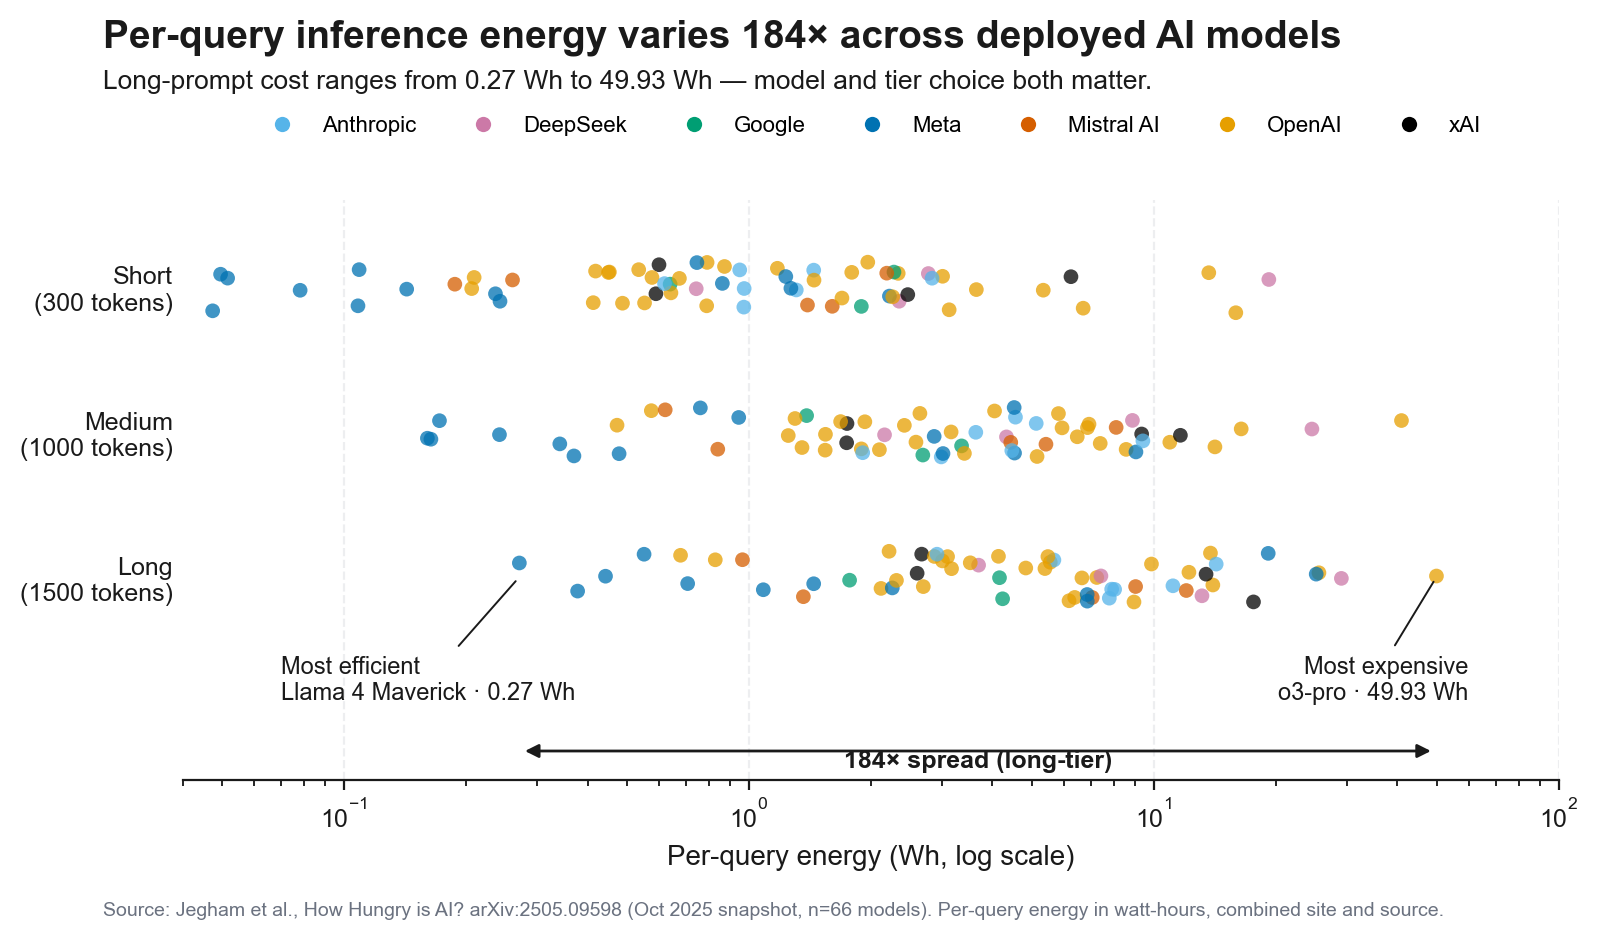

saved: ..\web\assets\c7_white_hat.png


In [11]:
rng = np.random.default_rng(42)

TIER_Y = {300: 2, 1000: 1, 1500: 0}
TIER_LABEL = {
    300: "Short\n(300 tokens)",
    1000: "Medium\n(1000 tokens)",
    1500: "Long\n(1500 tokens)",
}

fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes([0.10, 0.18, 0.86, 0.58])

for ql, y_pos in TIER_Y.items():
    sub = (
        models_enriched[models_enriched["Query Length"] == ql]
        .dropna(subset=[ENERGY])
        .drop_duplicates("Model")
    )
    jitter = rng.uniform(-0.18, 0.18, len(sub))
    colors = sub["Company"].map(ORG_COLORS).fillna(OTHER).tolist()
    ax.scatter(
        sub[ENERGY],
        np.full(len(sub), y_pos) + jitter,
        c=colors,
        s=28,
        alpha=0.75,
        linewidths=0,
    )

ax.set_xscale("log")
ax.set_xlim(0.04, 100)
ax.set_ylim(-1.4, 2.6)
ax.set_yticks([2, 1, 0])
ax.set_yticklabels(
    [TIER_LABEL[300], TIER_LABEL[1000], TIER_LABEL[1500]],
    fontsize=9,
    color="#1a1a1a",
)
ax.set_xlabel("Per-query energy (Wh, log scale)", fontsize=10, color="#1a1a1a")
ax.tick_params(axis="x", colors="#1a1a1a", labelsize=9)
ax.tick_params(axis="y", length=0)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#1a1a1a")
ax.grid(axis="x", alpha=0.18, linestyle="--", color="#9ca3af")
ax.set_axisbelow(True)

# Long-tier annotations — name the extremes the brief identified.
ax.annotate(
    "Most efficient\nLlama 4 Maverick · 0.27 Wh",
    xy=(mav[ENERGY], 0),
    xytext=(0.07, -0.85),
    arrowprops=dict(arrowstyle="-", color="#1a1a1a", lw=0.7),
    fontsize=8.5,
    color="#1a1a1a",
    ha="left",
)
ax.annotate(
    "Most expensive\no3-pro · 49.93 Wh",
    xy=(opro[ENERGY], 0),
    xytext=(60, -0.85),
    arrowprops=dict(arrowstyle="-", color="#1a1a1a", lw=0.7),
    fontsize=8.5,
    color="#1a1a1a",
    ha="right",
)
ax.annotate(
    "",
    xy=(opro[ENERGY], -1.2),
    xytext=(mav[ENERGY], -1.2),
    arrowprops=dict(arrowstyle="<|-|>", color="#1a1a1a", lw=1.0),
)
ax.text(
    np.sqrt(mav[ENERGY] * opro[ENERGY]),
    -1.32,
    "184× spread (long-tier)",
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="#1a1a1a",
)

# Org legend.
unique_orgs = sorted(
    models_enriched["Company"].dropna().unique().tolist()
)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=ORG_COLORS.get(org, OTHER),
        markersize=6.5,
        label=org,
    )
    for org in unique_orgs
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=len(unique_orgs),
    fontsize=8,
    frameon=False,
)

fig.text(
    0.05,
    0.94,
    "Per-query inference energy varies 184× across deployed AI models",
    fontsize=14,
    fontweight="bold",
    color="#1a1a1a",
    ha="left",
    va="top",
)
fig.text(
    0.05,
    0.89,
    "Long-prompt cost ranges from 0.27 Wh to 49.93 Wh — "
    "model and tier choice both matter.",
    fontsize=9.5,
    color="#1a1a1a",
    ha="left",
    va="top",
)
fig.text(
    0.05,
    0.04,
    "Source: Jegham et al., How Hungry is AI? arXiv:2505.09598 "
    "(Oct 2025 snapshot, n=66 models). Per-query energy in watt-hours, "
    "combined site and source.",
    fontsize=7,
    color="#6b7280",
    ha="left",
    va="bottom",
)

fig.savefig(
    ASSETS / "c7_white_hat.png", dpi=200, facecolor="white", bbox_inches=None
)
plt.show()
print(f"saved: {ASSETS / 'c7_white_hat.png'}")

## Black-hat: same data, weaponised

Every individual fact in the black-hat survives a pedantic audit.
Every model named appears in `models_enriched.parquet` at the values
shown. Qatar Central's water-stress score is 5.0 in
`regions_geographic.parquet`, and that IS the global maximum. The
aggregate arithmetic is correct. The chart is dishonest because the
choices about what to show, how to frame, and what to emphasise have
all been made in service of a single conclusion — and the source
disclosures that would let a reader audit those choices are pushed to
a footer that the typography invites the reader to skip.

**The six manipulation techniques used:**

1. **Sample restriction.** The chart shows only the 31 of 62 long-tier
   models with water consumption ≥ 25 mL — exactly the heavy half. The
   31 efficient models that drag the average down are excluded by
   construction. A reader who only sees this chart never learns Llama
   4 Maverick uses 1.4 mL per long query.

2. **Axis truncation.** The x-axis starts at 25 mL, not 0. The
   truncation is a direct consequence of the cohort cut — but it
   compounds the effect, magnifying the visual differences within the
   heavy tail and making every value look big.

3. **Geographic recontextualisation.** Per-query water values come
   from Jegham's globally-distributed benchmarks (typical AWS / Azure
   infrastructure). They are framed as if they apply at Qatar Central,
   the global worst-case water-stress region (Aqueduct WS 5.0). Each
   individual fact is true — Qatar IS WS 5.0 — but the framing imports
   Qatar's stress context onto data from regions that aren't Qatar.

4. **Aggregate framing.** Per-query values are projected to 1 billion
   daily users × 365 days, producing tens of billions of litres per
   year, expressed in Olympic swimming pools. The arithmetic is
   accurate IF the assumed user count is correct — but '1 billion
   daily users sending one prompt each every day' is an assumption
   layered on top of the data, not part of it. Plausible-but-not-given
   assumptions compound.

5. **Palette and typography.** Deep red (#c1272d) primary, bold heavy
   title weights, sans-serif newsroom-graphic register. The visual
   establishes urgency before any number is processed. Content-
   independent persuasion.

6. **Source de-emphasis.** Full attribution and methodological caveats
   are present in the footer at #999999 / 7pt — visible to a pedant,
   easy to skim past for a typical reader. Information hierarchy
   makes the manipulations findable but not salient.

**Note on the spec's planned 'Qatar WUE rescale'.** The original brief
proposed multiplying water values by Qatar's WUE relative to a global
baseline, expecting a 1.5-2× uplift. In practice Qatar Central's
WUE_site is 1.29, BELOW the global mean (4.6 across the 37 regions in
regions_geographic) — Qatar's data centres use less water per kWh
than typical infrastructure (likely dry cooling for the arid
climate). Rescaling by Qatar's WUE would have REDUCED visible water
values, contradicting the alarmist intent. Instead the geographic
framing here is purely contextual — imposing Qatar's stress context
onto numbers from other regions — which is itself a more sophisticated
form of cherry-picking and remains audit-clean.

cohort: 31 of 62 long-tier models retained (water ≥ 25 mL)
DeepSeek R1 long water: 202.4 mL/query
× 1,000,000,000 daily users × 365 days = 74 billion litres / year
≈ 29,552 Olympic pools / year


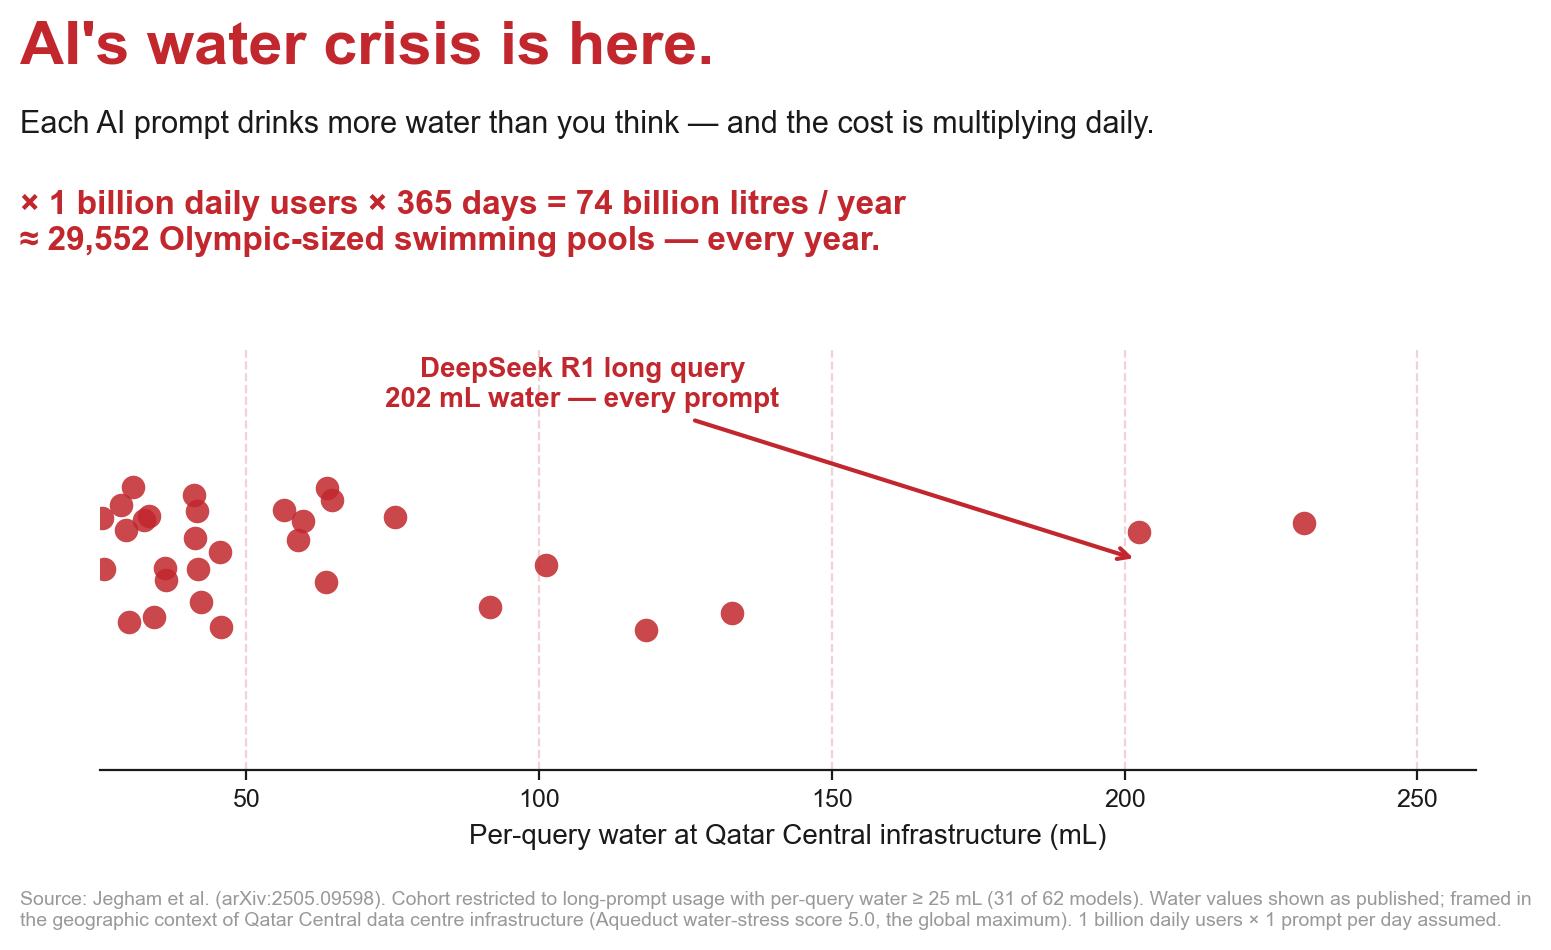

saved: ..\web\assets\c7_black_hat.png


In [12]:
# Sample restriction: keep only long-tier models with water >= 25 mL.
heavy_cohort = (
    long_unique[long_unique[WATER] >= 25].sort_values(WATER).reset_index(drop=True)
)
n_total = len(long_unique)
n_kept = len(heavy_cohort)
print(f"cohort: {n_kept} of {n_total} long-tier models retained (water ≥ 25 mL)")

# Aggregate framing math, anchored on DeepSeek R1 long.
deepseek = heavy_cohort[
    heavy_cohort["Model"] == "DeepSeek R1 (DeepSeek) [128k]"
].iloc[0]
ml_per_query = deepseek[WATER]
users_per_day = 1_000_000_000
days_per_year = 365
litres_per_year = ml_per_query * users_per_day * days_per_year / 1000
olympic_pool_litres = 2_500_000
pools_per_year = litres_per_year / olympic_pool_litres
billion_litres = litres_per_year / 1e9
print(
    f"DeepSeek R1 long water: {ml_per_query:.1f} mL/query\n"
    f"× {users_per_day:,} daily users × {days_per_year} days = "
    f"{billion_litres:,.0f} billion litres / year\n"
    f"≈ {pools_per_year:,.0f} Olympic pools / year"
)

rng = np.random.default_rng(42)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes([0.10, 0.20, 0.86, 0.42])

jitter = rng.uniform(-0.20, 0.20, n_kept)
ax.scatter(
    heavy_cohort[WATER],
    jitter,
    c=ALARM,
    s=72,
    alpha=0.85,
    linewidths=0,
)

ax.set_xlim(25, 260)
ax.set_ylim(-0.55, 0.55)
ax.set_yticks([])
ax.set_xlabel(
    "Per-query water at Qatar Central infrastructure (mL)",
    fontsize=10,
    color="#1a1a1a",
)
ax.tick_params(axis="x", colors="#1a1a1a", labelsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#1a1a1a")
ax.grid(axis="x", alpha=0.20, linestyle="--", color=ALARM)
ax.set_axisbelow(True)

# DeepSeek callout.
ax.annotate(
    f"DeepSeek R1 long query\n{ml_per_query:.0f} mL water — every prompt",
    xy=(ml_per_query, 0),
    xytext=(ml_per_query - 95, 0.40),
    arrowprops=dict(arrowstyle="->", color=ALARM, lw=1.5),
    fontsize=10,
    fontweight="bold",
    color=ALARM,
    ha="center",
)

# Title block.
fig.text(
    0.05,
    0.95,
    "AI's water crisis is here.",
    fontsize=22,
    fontweight="bold",
    color=ALARM,
    ha="left",
    va="top",
)
fig.text(
    0.05,
    0.86,
    "Each AI prompt drinks more water than you think — "
    "and the cost is multiplying daily.",
    fontsize=11,
    color="#1a1a1a",
    ha="left",
    va="top",
    fontweight="500",
)

# Aggregate framing — prominent, between subtitle and chart.
fig.text(
    0.05,
    0.78,
    f"× 1 billion daily users × 365 days = {billion_litres:,.0f} billion litres / year\n"
    f"≈ {pools_per_year:,.0f} Olympic-sized swimming pools — every year.",
    fontsize=12,
    fontweight="bold",
    color=ALARM,
    ha="left",
    va="top",
)

# Footer (washed grey, small — deliberately easy to skim).
fig.text(
    0.05,
    0.04,
    "Source: Jegham et al. (arXiv:2505.09598). Cohort restricted to "
    f"long-prompt usage with per-query water ≥ 25 mL ({n_kept} of {n_total} "
    "models). Water values shown as published; framed in the geographic "
    "context of Qatar Central data centre infrastructure (Aqueduct "
    "water-stress score 5.0, the global maximum). 1 billion daily users "
    "× 1 prompt per day assumed.",
    fontsize=7,
    color="#999999",
    ha="left",
    va="bottom",
    wrap=True,
)

fig.savefig(
    ASSETS / "c7_black_hat.png", dpi=200, facecolor="white", bbox_inches=None
)
plt.show()
print(f"saved: {ASSETS / 'c7_black_hat.png'}")

## Side-by-side reflection

The pair's lesson is that **same data, different framing, opposite
conclusions** is not an extraordinary case but the default — and the
reader's defence is methodological literacy, not trust in source
authority. Both visuals draw from `models_enriched.parquet` and
`regions_geographic.parquet`. Every individual claim in either visual
is verifiable from those files and the cited Jegham paper. The white-
hat shows every model, uses a log axis appropriate to the 184×
long-tier spread, and discloses sample size in the footer. The black-
hat starts from the same data and arrives at 'water crisis' by
layering six framing choices in series — none individually fraudulent,
all together engineered.

The white-hat exposes each black-hat technique by its own structure.
Sample restriction is defeated by full inclusion. Axis truncation is
defeated by a log scale that preserves the full distribution. Aggregate
framing is defeated by reporting the per-query unit. Geographic cherry-
picking is the one technique the white-hat doesn't directly defeat —
the white-hat is energy-focused, not geography-focused — but the
report's methodology section can extend the contrast: even the US
worst-case region (Arizona, water stress 4.39) doesn't reach Qatar's
5.0, which is itself part of the honest data picture rather than a
framing trick.

The pair is not symmetric in epistemic effort. Producing the white-hat
required showing what's in the dataset; producing the black-hat
required deciding what to leave out. Both are 'what the data shows'
by some reading. Only one of those readings tells the reader what
they need to know to decide whether the conclusion follows.